<a href="https://colab.research.google.com/github/Jbaner/OMDSModC_Capstone_Project/blob/main/OMDS_ModC_Week5_Banerjee_Jayeeta.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [15]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVC
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, precision_score,recall_score, f1_score, roc_auc_score, ConfusionMatrixDisplay,confusion_matrix,classification_report,RocCurveDisplay
import matplotlib.pyplot as plt

In [ ]:
datasource= "https://archive.ics.uci.edu/static/public/17/data.csv"

df_BreastCancer = pd.read_csv(datasource, sep=',', header=0) #loading breast cancer dataset
df_BreastCancer.sample(10, random_state=42) #printing random sample of 10 rows

In [10]:
df_BreastCancer["Diagnosis"]=df_BreastCancer["Diagnosis"].map({"M":0, "B":1})

In [11]:
#Target and Features
X= df_BreastCancer.drop(["Diagnosis","ID"], axis=1)
y= df_BreastCancer["Diagnosis"]
#Train Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state=42)

In [14]:

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled =  scaler.transform(X_test)

#Linear SVM
svm_linear = SVC(kernel='linear', C=1.0, random_state=42)
svm_linear.fit(X_train_scaled, y_train)
y_pred_linear = svm_linear.predict(X_test_scaled)

#Evaluation
linear_acc = accuracy_score(y_test, y_pred_linear)
cm1 = confusion_matrix(y_test, y_pred_linear)
cr1 = classification_report(y_test, y_pred_linear)
print("\nLinear SVM Confusion Matrix: \n", cm1)
print("\n Linear SVM Classification Report: \n\n", cr1)
print("\n-----------------------------------------------------------------")

#Poly SVM
svm_poly = SVC(kernel ='poly', degree=3, C=1.0)
svm_poly.fit(X_train_scaled, y_train)
y_pred_poly = svm_poly.predict(X_test_scaled)

#Evaluation
Poly_acc = accuracy_score(y_test, y_pred_poly)
cm2 = confusion_matrix(y_test, y_pred_poly)
cr2 = classification_report(y_test, y_pred_poly)
print("\nPoly SVM Confusion Matrix: \n", cm2)
print("\n Poly SVM Classification Report: \n\n", cr2)
print("\n-----------------------------------------------------------------")

#RBF (Gaussian) Kernel
svm_rbf = SVC(kernel='rbf', C=1.0, gamma='scale')
svm_rbf.fit(X_train_scaled, y_train)
y_pred_rbf = svm_rbf.predict(X_test_scaled)

#Evaluation
rbf_acc = accuracy_score(y_test, y_pred_rbf)
cm3 = confusion_matrix(y_test, y_pred_rbf)
cr3 = classification_report(y_test, y_pred_rbf)
print("\nRBF SVM Confusion Matrix: \n", cm3)
print("\n RBF SVM Classification Report: \n\n", cr3)





Linear SVM Confusion Matrix: 
 [[52  2]
 [ 2 87]]

 Linear SVM Classification Report: 

               precision    recall  f1-score   support

           0       0.96      0.96      0.96        54
           1       0.98      0.98      0.98        89

    accuracy                           0.97       143
   macro avg       0.97      0.97      0.97       143
weighted avg       0.97      0.97      0.97       143


-----------------------------------------------------------------

Poly SVM Confusion Matrix: 
 [[40 14]
 [ 0 89]]

 Poly SVM Classification Report: 

               precision    recall  f1-score   support

           0       1.00      0.74      0.85        54
           1       0.86      1.00      0.93        89

    accuracy                           0.90       143
   macro avg       0.93      0.87      0.89       143
weighted avg       0.92      0.90      0.90       143


-----------------------------------------------------------------

RBF SVM Confusion Matrix: 
 [[52  2

In [16]:
#Regularization in SVM Hyperparameter Tuning
param_grid = {'C': [0.01,0.1,1,10,100],
              'gamma': [0.001, 0.01, 0.1,1],
              'kernel': ['rbf']
              }
grid = GridSearchCV(SVC(),param_grid, cv=5, scoring = 'accuracy')
grid.fit(X_train_scaled, y_train)
print(grid.best_params_)



{'C': 100, 'gamma': 0.001, 'kernel': 'rbf'}


In [17]:
#Regularization in SVM Hyperparameter Tuning
param_grid = {'C': [0.01,0.1,1,10,100],
              'gamma': [0.001, 0.01, 0.1,1],
              'kernel': ['poly']
              }
grid = GridSearchCV(SVC(),param_grid, cv=5, scoring = 'accuracy')
grid.fit(X_train_scaled, y_train)
print(grid.best_params_)

{'C': 1, 'gamma': 0.1, 'kernel': 'poly'}


In [18]:
#Regularization in SVM Hyperparameter Tuning
param_grid = {'C': [0.01,0.1,1,10,100],
              'gamma': [0.001, 0.01, 0.1,1],
              'kernel': ['linear']
              }
grid = GridSearchCV(SVC(),param_grid, cv=5, scoring = 'accuracy')
grid.fit(X_train_scaled, y_train)
print(grid.best_params_)

{'C': 0.1, 'gamma': 0.001, 'kernel': 'linear'}


In [21]:
#Hyperparameter Tuning for best model
param_grid = {'C': [0.01,0.1,1,10,100],
              'gamma': [0.001, 0.01, 0.1,1],
              'kernel': ['linear','poly','rbf']
              }
grid = GridSearchCV(SVC(),param_grid, cv=5, scoring = 'accuracy')
grid.fit(X_train_scaled, y_train)
print(grid.best_params_)

{'C': 0.1, 'gamma': 0.001, 'kernel': 'linear'}


In [28]:
#Generating best model using the best parameters
svm_linear = SVC(kernel='linear', C=0.1, gamma=0.001, random_state=42)
svm_linear.fit(X_train_scaled, y_train)
y_pred_linear2 = svm_linear.predict(X_test_scaled)
#Evaluation
linear_acc2 = accuracy_score(y_test, y_pred_linear2)
cm = confusion_matrix(y_test, y_pred_linear2)
cr = classification_report(y_test, y_pred_linear2)
print("\nLinear SVM Confusion Matrix: \n", cm)
print("\n Linear SVM Classification Report: \n\n", cr)



Linear SVM Confusion Matrix: 
 [[52  2]
 [ 1 88]]

 Linear SVM Classification Report: 

               precision    recall  f1-score   support

           0       0.98      0.96      0.97        54
           1       0.98      0.99      0.98        89

    accuracy                           0.98       143
   macro avg       0.98      0.98      0.98       143
weighted avg       0.98      0.98      0.98       143



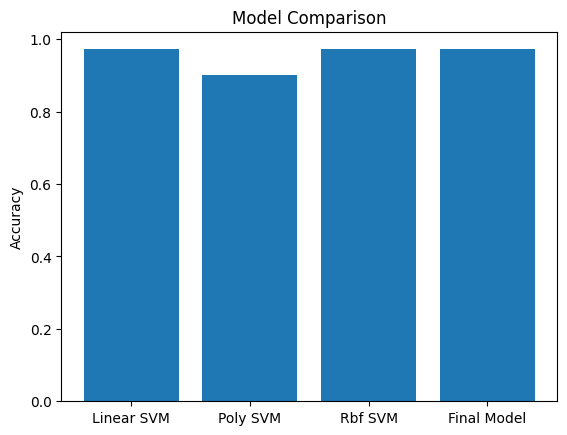

In [32]:
#Model comparison linear poly rbf and final model
plt.bar(['Linear SVM','Poly SVM','Rbf SVM','Final Model'],
        [linear_acc, Poly_acc, rbf_acc, linear_acc])
plt.ylabel("Accuracy")
plt.title("Model Comparison")
plt.show()


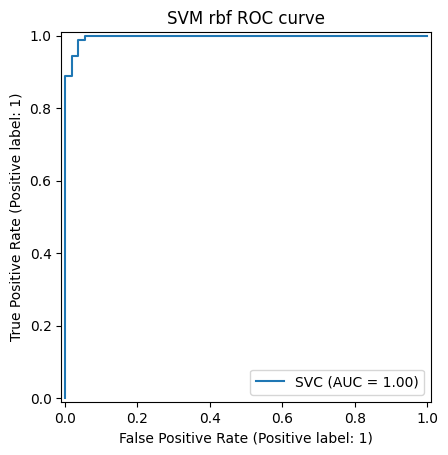

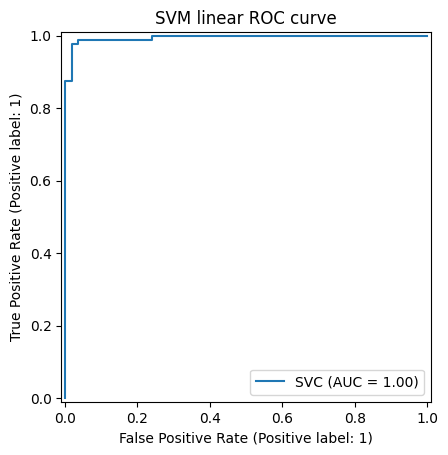

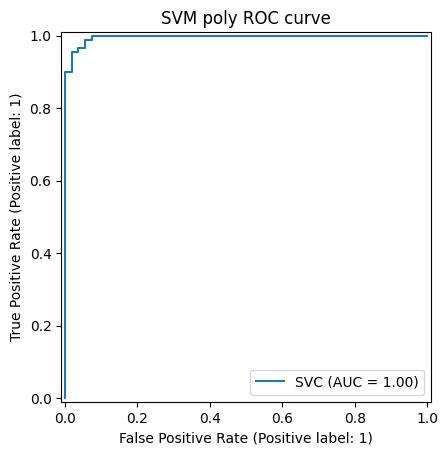

In [26]:
#Roc curve for all kernels
RocCurveDisplay.from_estimator(svm_rbf, X_test_scaled, y_test)
plt.title("SVM rbf ROC curve")
plt.show()

RocCurveDisplay.from_estimator(svm_linear, X_test_scaled, y_test)
plt.title("SVM linear ROC curve")
plt.show()

RocCurveDisplay.from_estimator(svm_poly, X_test_scaled, y_test)
plt.title("SVM poly ROC curve")
plt.show()